## the workflow:

1. generate training data: generate_ace_training_data.py
2. train the nn: train_ace_nn.py
3. generate the dataset for evaluation in SEM and SBI: simulate_ACE_test.R
4. fit SEM: simulate_ACE_test.R
5. fit SBI: npe_ace_simulation.py or npe_ace_simulation_no_n.py
6. come the analysis script to visualize results.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

SCRIPT_DIR = Path(".")  # run from ACE_Scripts/

# ── Load data ──────────────────────────────────────────────────────────────
omx = pd.read_csv(SCRIPT_DIR / "ace_simulation_results.csv")
npe = pd.read_csv(SCRIPT_DIR / "npe_simulation_results.csv")

# Keep only converged OpenMx fits
omx = omx[omx["converged"] == 1].copy()

print(f"OpenMx rows (converged): {len(omx)}")
print(f"NPE rows:                {len(npe)}")
print(f"Sample sizes: {sorted(omx['sample_size'].unique())}")

OpenMx rows (converged): 1389
NPE rows:                1400
Sample sizes: [np.int64(50), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(20000)]


In [37]:
# ── Aggregate statistics ───────────────────────────────────────────────────
SAMPLE_SIZES = sorted(omx["sample_size"].unique())
PARAMS = ["A", "C", "E"]

def aggregate(df, stat_fn, col_template):
    """Group by sample_size, apply stat_fn to each parameter column."""
    records = []
    for n in SAMPLE_SIZES:
        sub = df[df["sample_size"] == n]
        row = {"sample_size": n}
        for p in PARAMS:
            col = col_template.format(p)
            row[p] = stat_fn(sub[col].dropna())
        records.append(row)
    return pd.DataFrame(records).set_index("sample_size")

# Empirical SD of estimates across conditions
omx_var_est = aggregate(omx, np.std, "{}_est")
npe_var_est = aggregate(npe, np.std, "{}_est")

# Mean SE across conditions
omx_mean_se = aggregate(omx, np.mean, "{}_se")
npe_mean_se = aggregate(npe, np.mean, "{}_se")

print("Empirical SD of estimates (OpenMx):")
print(omx_var_est.round(6))
print("\nEmpirical SD of estimates (NPE):")
print(npe_var_est.round(6))

Empirical SD of estimates (OpenMx):
                    A         C         E
sample_size                              
50           0.251483  0.256613  0.236645
100          0.244243  0.256238  0.244953
200          0.244078  0.244702  0.235260
500          0.231303  0.244240  0.233281
1000         0.233388  0.243044  0.233571
2000         0.233569  0.242007  0.233704
20000        0.228081  0.239573  0.232747

Empirical SD of estimates (NPE):
                    A         C         E
sample_size                              
50           0.221909  0.226276  0.246891
100          0.254174  0.223326  0.242048
200          0.269475  0.241103  0.247468
500          0.253238  0.239970  0.234597
1000         0.243711  0.231859  0.228741
2000         0.244682  0.234902  0.226348
20000        0.240455  0.237220  0.224754


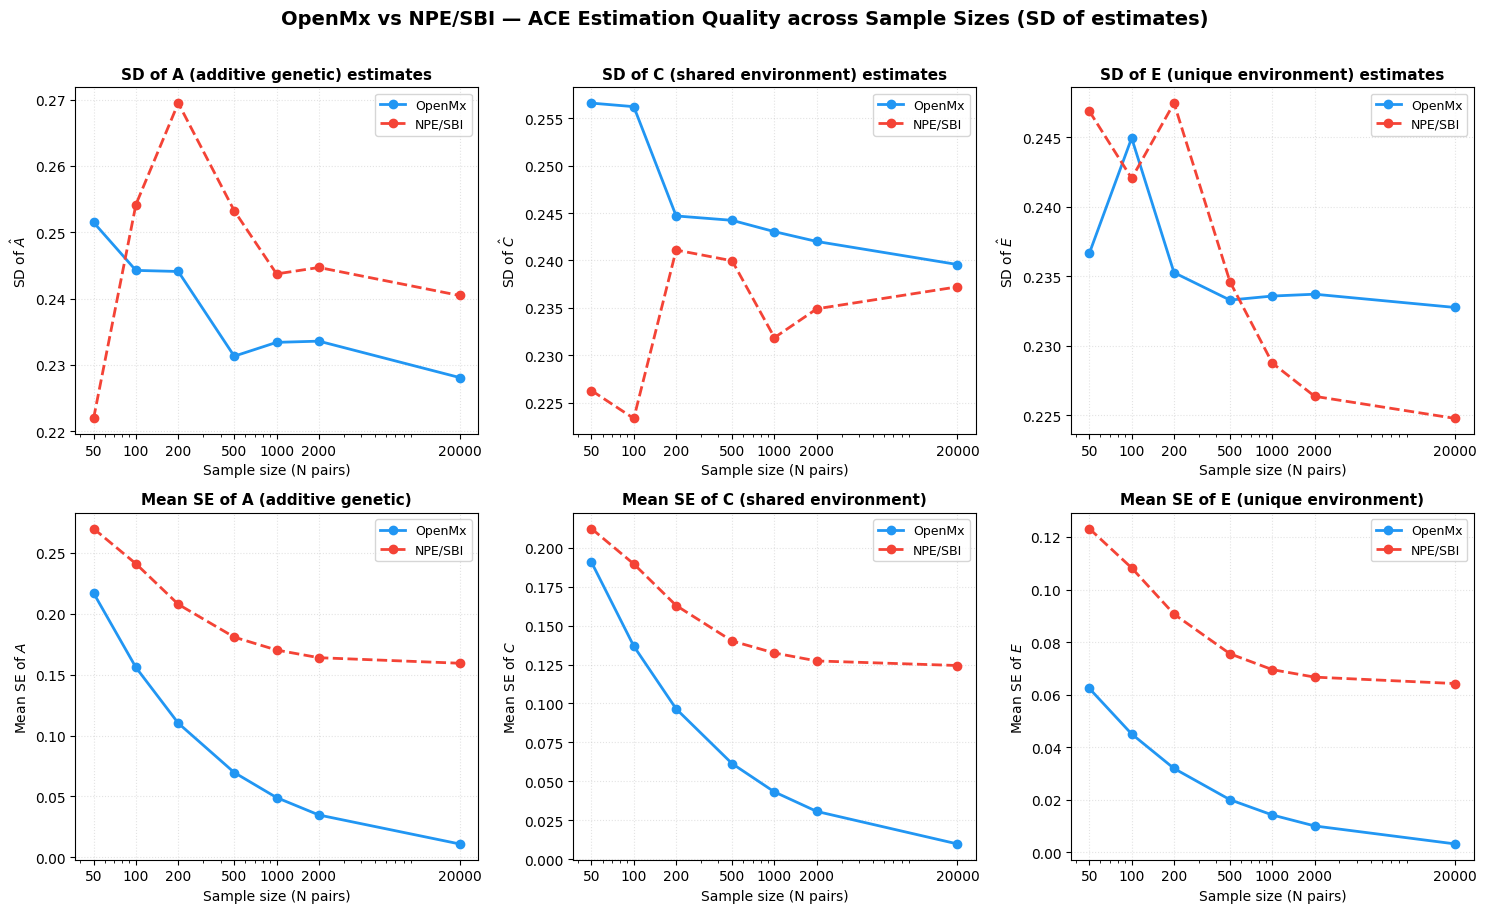

Saved to ace_comparison_plots.png


In [38]:
# ── Plot settings ──────────────────────────────────────────────────────────
OMX_COLOR = "#2196F3"   # blue
NPE_COLOR = "#F44336"   # red
MARKER    = "o"
LW        = 2.0
MS        = 6

PARAM_LABELS = {"A": "A (additive genetic)",
                "C": "C (shared environment)",
                "E": "E (unique environment)"}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("OpenMx vs NPE/SBI — ACE Estimation Quality across Sample Sizes (SD of estimates)",
             fontsize=14, fontweight="bold", y=1.01)

xs = np.array(SAMPLE_SIZES)

# ── Row 1: Empirical SD of estimates ─────────────────────────────────────
for col, param in enumerate(PARAMS):
    ax = axes[0, col]
    ax.plot(xs, omx_var_est[param].values, color=OMX_COLOR,
            marker=MARKER, linewidth=LW, markersize=MS, label="OpenMx")
    ax.plot(xs, npe_var_est[param].values, color=NPE_COLOR,
            marker=MARKER, linewidth=LW, markersize=MS, linestyle="--", label="NPE/SBI")
    ax.set_title(f"SD of {PARAM_LABELS[param]} estimates",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Sample size (N pairs)", fontsize=10)
    ax.set_ylabel("SD of $\\hat{%s}$" % param, fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(xs)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35, linestyle=":")

# ── Row 2: Mean SE ─────────────────────────────────────────────────────────
for col, param in enumerate(PARAMS):
    ax = axes[1, col]
    ax.plot(xs, omx_mean_se[param].values, color=OMX_COLOR,
            marker=MARKER, linewidth=LW, markersize=MS, label="OpenMx")
    ax.plot(xs, npe_mean_se[param].values, color=NPE_COLOR,
            marker=MARKER, linewidth=LW, markersize=MS, linestyle="--", label="NPE/SBI")
    ax.set_title(f"Mean SE of {PARAM_LABELS[param]}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Sample size (N pairs)", fontsize=10)
    ax.set_ylabel("Mean SE of $%s$" % param, fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(xs)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35, linestyle=":")

plt.tight_layout()
out_path = SCRIPT_DIR / "ace_comparison_plots.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")

NPE mean bias (est − true) by sample size

     N      A bias      C bias      E bias
--------------------------------------------
    50     +0.0606     -0.0069     -0.0533
   100     +0.0578     -0.0165     -0.0408
   200     +0.0364     +0.0019     -0.0379
   500     +0.0469     -0.0128     -0.0338
  1000     +0.0247     +0.0045     -0.0289
  2000     +0.0289     -0.0027     -0.0259
 20000     +0.0083     +0.0157     -0.0237

OpenMx mean bias (est − true) by sample size

     N      A bias      C bias      E bias
--------------------------------------------
    50     -0.0157     +0.0197     -0.0040
   100     -0.0031     +0.0020     +0.0011
   200     -0.0062     +0.0042     +0.0020
   500     +0.0041     -0.0034     -0.0007
  1000     +0.0017     -0.0001     -0.0017
  2000     +0.0008     +0.0001     -0.0010
 20000     +0.0003     -0.0004     +0.0001


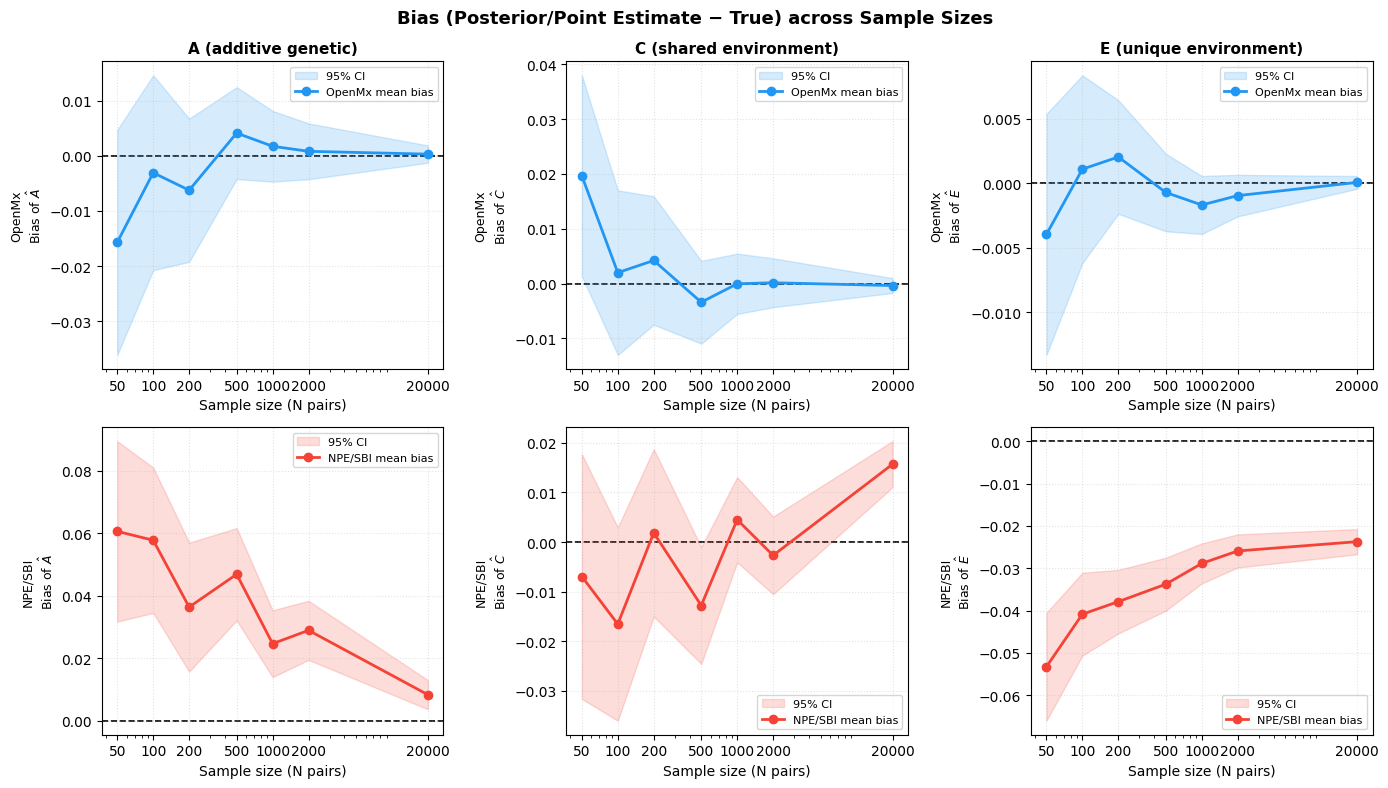

Saved to bias_comparison_plot.png


In [39]:

def bias_se(x):
    """SE of the mean bias estimate."""
    x = x.dropna()
    return np.std(x, ddof=1) / np.sqrt(len(x))

# ── NPE Bias Analysis ──────────────────────────────────────────────────────
npe_bias = aggregate(
    npe.assign(
        A_bias=npe["A_est"] - npe["true_A"],
        C_bias=npe["C_est"] - npe["true_C"],
        E_bias=npe["E_est"] - npe["true_E"],
    ),
    np.mean,
    "{}_bias",
)

npe_bias_se = aggregate(
    npe.assign(
        A_bias=npe["A_est"] - npe["true_A"],
        C_bias=npe["C_est"] - npe["true_C"],
        E_bias=npe["E_est"] - npe["true_E"],
    ),
    bias_se,
    "{}_bias",
)

# ── OpenMx Bias Analysis ───────────────────────────────────────────────────
omx_bias = aggregate(
    omx.assign(
        A_bias=omx["A_est"] - omx["true_A"],
        C_bias=omx["C_est"] - omx["true_C"],
        E_bias=omx["E_est"] - omx["true_E"],
    ),
    np.mean,
    "{}_bias",
)

omx_bias_se = aggregate(
    omx.assign(
        A_bias=omx["A_est"] - omx["true_A"],
        C_bias=omx["C_est"] - omx["true_C"],
        E_bias=omx["E_est"] - omx["true_E"],
    ),
    bias_se,
    "{}_bias",
)

# ── Print summary tables ───────────────────────────────────────────────────
print("NPE mean bias (est − true) by sample size\n")
print(f"{'N':>6}  {'A bias':>10}  {'C bias':>10}  {'E bias':>10}")
print("-" * 44)
for n in SAMPLE_SIZES:
    print(f"{n:>6}  {npe_bias.loc[n,'A']:>+10.4f}  "
          f"{npe_bias.loc[n,'C']:>+10.4f}  "
          f"{npe_bias.loc[n,'E']:>+10.4f}")

print("\nOpenMx mean bias (est − true) by sample size\n")
print(f"{'N':>6}  {'A bias':>10}  {'C bias':>10}  {'E bias':>10}")
print("-" * 44)
for n in SAMPLE_SIZES:
    print(f"{n:>6}  {omx_bias.loc[n,'A']:>+10.4f}  "
          f"{omx_bias.loc[n,'C']:>+10.4f}  "
          f"{omx_bias.loc[n,'E']:>+10.4f}")

# ── Side-by-side comparison plot ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
fig.suptitle("Bias (Posterior/Point Estimate − True) across Sample Sizes",
             fontsize=13, fontweight="bold")

for col, param in enumerate(PARAMS):
    for row, (bias_df, bias_se_df, color, label) in enumerate([
        (omx_bias,  omx_bias_se,  OMX_COLOR, "OpenMx"),
        (npe_bias,  npe_bias_se,  NPE_COLOR, "NPE/SBI"),
    ]):
        ax   = axes[row, col]
        bias = bias_df[param].values
        ci   = 1.96 * bias_se_df[param].values

        ax.axhline(0, color="black", linewidth=1.2, linestyle="--", zorder=1)
        ax.fill_between(xs, bias - ci, bias + ci,
                        color=color, alpha=0.18, label="95% CI")
        ax.plot(xs, bias, color=color, marker=MARKER,
                linewidth=LW, markersize=MS, label=f"{label} mean bias", zorder=3)

        if row == 0:
            ax.set_title(f"{PARAM_LABELS[param]}", fontsize=11, fontweight="bold")
        ax.set_ylabel(f"{label}\nBias of $\\hat{{{param}}}$", fontsize=9)
        ax.set_xlabel("Sample size (N pairs)", fontsize=10)
        ax.set_xscale("log")
        ax.set_xticks(xs)
        ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.35, linestyle=":")

plt.tight_layout()
plt.savefig(SCRIPT_DIR / "bias_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to bias_comparison_plot.png")


NPE (no-N) rows: 1400
Sample sizes:    [np.int64(50), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(20000)]


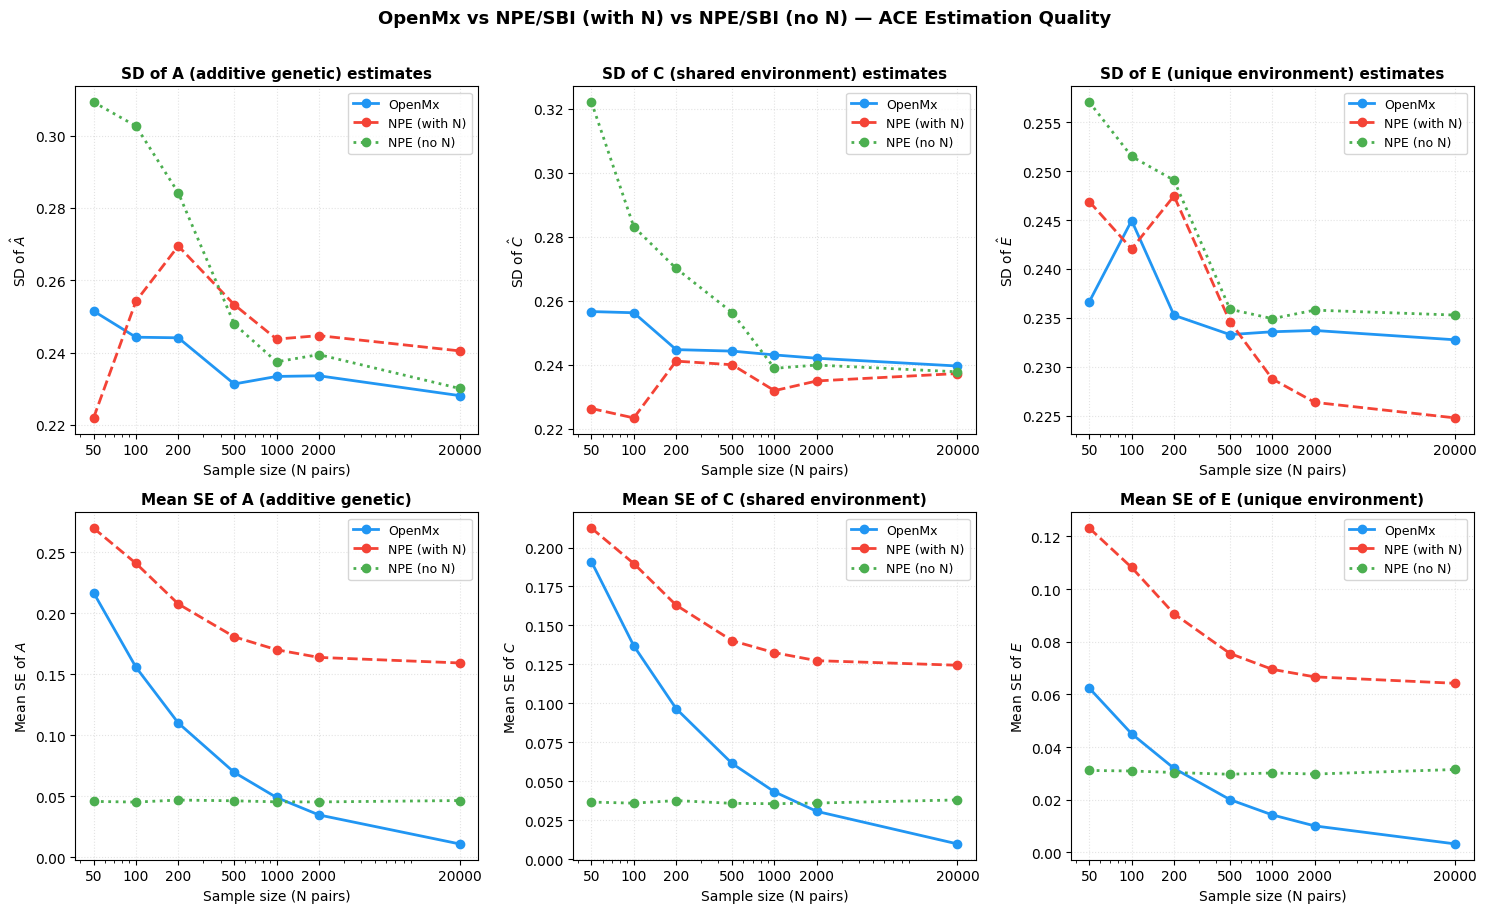

Saved to ace_comparison_plots_3way.png


In [40]:

# ── Load no-N model results ────────────────────────────────────────────────
npe_no_n = pd.read_csv(SCRIPT_DIR / "npe_simulation_results_no_n.csv")
print(f"NPE (no-N) rows: {len(npe_no_n)}")
print(f"Sample sizes:    {sorted(npe_no_n['sample_size'].unique())}")

NO_N_COLOR = "#4CAF50"   # green

# Empirical SD and mean SE for the no-N model
npe_no_n_var_est = aggregate(npe_no_n, np.std,  "{}_est")
npe_no_n_mean_se = aggregate(npe_no_n, np.mean, "{}_se")

# ── Plot 1: SD of estimates & Mean SE ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    "OpenMx vs NPE/SBI (with N) vs NPE/SBI (no N) — ACE Estimation Quality",
    fontsize=13, fontweight="bold", y=1.01,
)

# Row 1: Empirical SD of estimates
for col, param in enumerate(PARAMS):
    ax = axes[0, col]
    ax.plot(xs, omx_var_est[param].values,      color=OMX_COLOR,  marker=MARKER, linewidth=LW, markersize=MS, label="OpenMx")
    ax.plot(xs, npe_var_est[param].values,       color=NPE_COLOR,  marker=MARKER, linewidth=LW, markersize=MS, linestyle="--", label="NPE (with N)")
    ax.plot(xs, npe_no_n_var_est[param].values,  color=NO_N_COLOR, marker=MARKER, linewidth=LW, markersize=MS, linestyle=":",  label="NPE (no N)")
    ax.set_title(f"SD of {PARAM_LABELS[param]} estimates", fontsize=11, fontweight="bold")
    ax.set_xlabel("Sample size (N pairs)", fontsize=10)
    ax.set_ylabel("SD of $\\hat{%s}$" % param, fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(xs)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35, linestyle=":")

# Row 2: Mean SE
for col, param in enumerate(PARAMS):
    ax = axes[1, col]
    ax.plot(xs, omx_mean_se[param].values,      color=OMX_COLOR,  marker=MARKER, linewidth=LW, markersize=MS, label="OpenMx")
    ax.plot(xs, npe_mean_se[param].values,       color=NPE_COLOR,  marker=MARKER, linewidth=LW, markersize=MS, linestyle="--", label="NPE (with N)")
    ax.plot(xs, npe_no_n_mean_se[param].values,  color=NO_N_COLOR, marker=MARKER, linewidth=LW, markersize=MS, linestyle=":",  label="NPE (no N)")
    ax.set_title(f"Mean SE of {PARAM_LABELS[param]}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Sample size (N pairs)", fontsize=10)
    ax.set_ylabel("Mean SE of $%s$" % param, fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(xs)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35, linestyle=":")

plt.tight_layout()
out_path = SCRIPT_DIR / "ace_comparison_plots_3way.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")


NPE (no-N) mean bias (est − true) by sample size

     N      A bias      C bias      E bias
--------------------------------------------
    50     +0.0151     +0.0078     -0.0042
   100     +0.0003     +0.0074     +0.0095
   200     -0.0128     +0.0189     +0.0042
   500     +0.0098     -0.0041     +0.0011
  1000     -0.0024     +0.0061     -0.0023
  2000     +0.0076     -0.0042     -0.0011
 20000     -0.0010     +0.0040     +0.0002


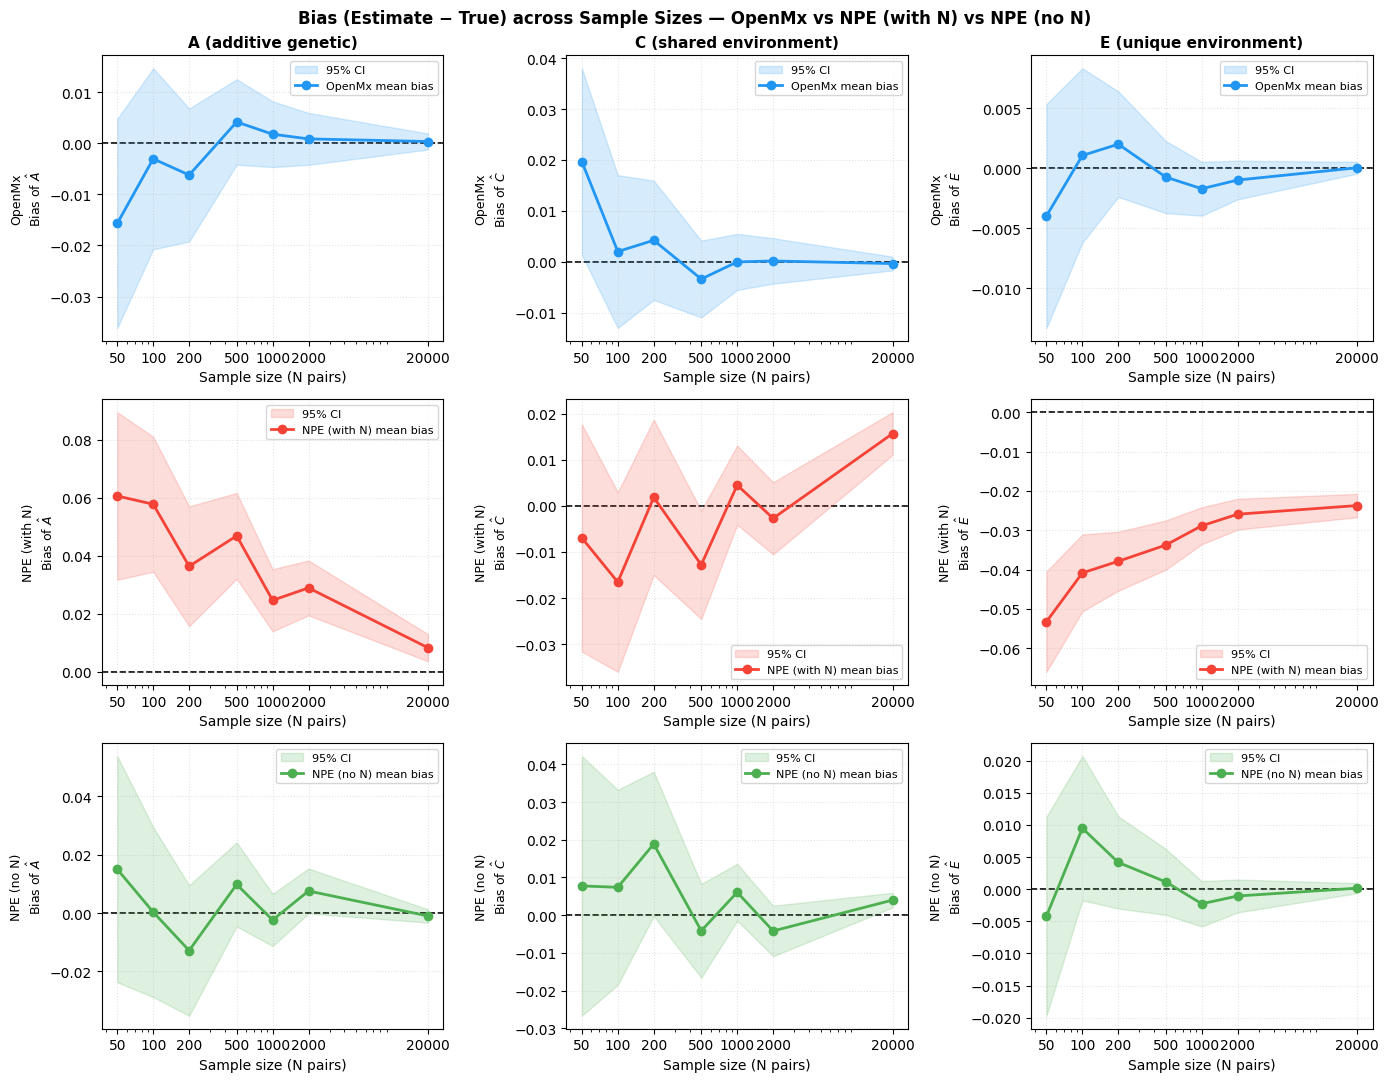

Saved to bias_comparison_plot_3way.png


In [41]:

# ── Bias for no-N model ────────────────────────────────────────────────────
npe_no_n_bias = aggregate(
    npe_no_n.assign(
        A_bias=npe_no_n["A_est"] - npe_no_n["true_A"],
        C_bias=npe_no_n["C_est"] - npe_no_n["true_C"],
        E_bias=npe_no_n["E_est"] - npe_no_n["true_E"],
    ),
    np.mean,
    "{}_bias",
)

npe_no_n_bias_se = aggregate(
    npe_no_n.assign(
        A_bias=npe_no_n["A_est"] - npe_no_n["true_A"],
        C_bias=npe_no_n["C_est"] - npe_no_n["true_C"],
        E_bias=npe_no_n["E_est"] - npe_no_n["true_E"],
    ),
    bias_se,
    "{}_bias",
)

# ── Print summary table ────────────────────────────────────────────────────
print("NPE (no-N) mean bias (est − true) by sample size\n")
print(f"{'N':>6}  {'A bias':>10}  {'C bias':>10}  {'E bias':>10}")
print("-" * 44)
for n in SAMPLE_SIZES:
    print(f"{n:>6}  {npe_no_n_bias.loc[n,'A']:>+10.4f}  "
          f"{npe_no_n_bias.loc[n,'C']:>+10.4f}  "
          f"{npe_no_n_bias.loc[n,'E']:>+10.4f}")

# ── 3-way bias comparison plot ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharey=False)
fig.suptitle(
    "Bias (Estimate − True) across Sample Sizes — OpenMx vs NPE (with N) vs NPE (no N)",
    fontsize=12, fontweight="bold",
)

for col, param in enumerate(PARAMS):
    for row, (bias_df, bias_se_df, color, label) in enumerate([
        (omx_bias,      omx_bias_se,      OMX_COLOR,  "OpenMx"),
        (npe_bias,      npe_bias_se,      NPE_COLOR,  "NPE (with N)"),
        (npe_no_n_bias, npe_no_n_bias_se, NO_N_COLOR, "NPE (no N)"),
    ]):
        ax   = axes[row, col]
        bias = bias_df[param].values
        ci   = 1.96 * bias_se_df[param].values

        ax.axhline(0, color="black", linewidth=1.2, linestyle="--", zorder=1)
        ax.fill_between(xs, bias - ci, bias + ci, color=color, alpha=0.18, label="95% CI")
        ax.plot(xs, bias, color=color, marker=MARKER,
                linewidth=LW, markersize=MS, label=f"{label} mean bias", zorder=3)

        if row == 0:
            ax.set_title(f"{PARAM_LABELS[param]}", fontsize=11, fontweight="bold")
        ax.set_ylabel(f"{label}\nBias of $\\hat{{{param}}}$", fontsize=9)
        ax.set_xlabel("Sample size (N pairs)", fontsize=10)
        ax.set_xscale("log")
        ax.set_xticks(xs)
        ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.35, linestyle=":")

plt.tight_layout()
plt.savefig(SCRIPT_DIR / "bias_comparison_plot_3way.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to bias_comparison_plot_3way.png")


NPE (no-N) MAP bias (MAP − true) by sample size

     N      A bias      C bias      E bias
--------------------------------------------
    50     +0.0151     +0.0072     -0.0045
   100     +0.0000     +0.0071     +0.0093
   200     -0.0132     +0.0185     +0.0039
   500     +0.0096     -0.0045     +0.0009
  1000     -0.0027     +0.0057     -0.0025
  2000     +0.0074     -0.0047     -0.0014
 20000     -0.0012     +0.0034     -0.0002


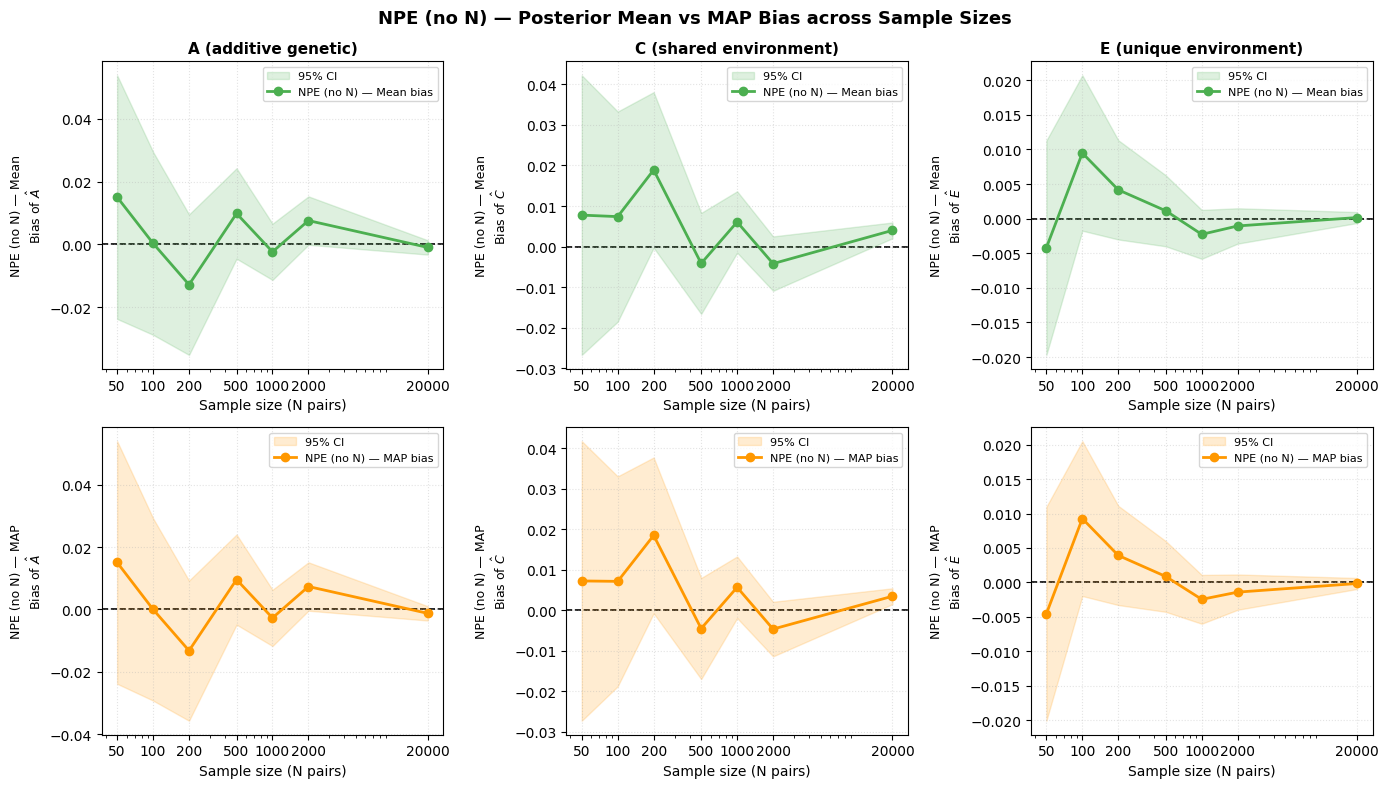

Saved to npe_no_n_map_bias_plot.png


In [42]:

# ── NPE (no-N) MAP Bias Analysis ───────────────────────────────────────────
npe_no_n_map_bias = aggregate(
    npe_no_n.assign(
        A_bias=npe_no_n["A_map"] - npe_no_n["true_A"],
        C_bias=npe_no_n["C_map"] - npe_no_n["true_C"],
        E_bias=npe_no_n["E_map"] - npe_no_n["true_E"],
    ),
    np.mean,
    "{}_bias",
)

npe_no_n_map_bias_se = aggregate(
    npe_no_n.assign(
        A_bias=npe_no_n["A_map"] - npe_no_n["true_A"],
        C_bias=npe_no_n["C_map"] - npe_no_n["true_C"],
        E_bias=npe_no_n["E_map"] - npe_no_n["true_E"],
    ),
    bias_se,
    "{}_bias",
)

# ── Print summary table ────────────────────────────────────────────────────
print("NPE (no-N) MAP bias (MAP − true) by sample size\n")
print(f"{'N':>6}  {'A bias':>10}  {'C bias':>10}  {'E bias':>10}")
print("-" * 44)
for n in SAMPLE_SIZES:
    print(f"{n:>6}  {npe_no_n_map_bias.loc[n,'A']:>+10.4f}  "
          f"{npe_no_n_map_bias.loc[n,'C']:>+10.4f}  "
          f"{npe_no_n_map_bias.loc[n,'E']:>+10.4f}")

# ── Side-by-side: posterior mean bias vs MAP bias for no-N model ──────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
fig.suptitle("NPE (no N) — Posterior Mean vs MAP Bias across Sample Sizes",
             fontsize=13, fontweight="bold")

MEAN_COLOR = NO_N_COLOR   # green for mean
MAP_COLOR  = "#FF9800"    # orange for MAP

for col, param in enumerate(PARAMS):
    for row, (bias_df, bias_se_df, color, label) in enumerate([
        (npe_no_n_bias,     npe_no_n_bias_se,     MEAN_COLOR, "NPE (no N) — Mean"),
        (npe_no_n_map_bias, npe_no_n_map_bias_se, MAP_COLOR,  "NPE (no N) — MAP"),
    ]):
        ax   = axes[row, col]
        bias = bias_df[param].values
        ci   = 1.96 * bias_se_df[param].values

        ax.axhline(0, color="black", linewidth=1.2, linestyle="--", zorder=1)
        ax.fill_between(xs, bias - ci, bias + ci,
                        color=color, alpha=0.18, label="95% CI")
        ax.plot(xs, bias, color=color, marker=MARKER,
                linewidth=LW, markersize=MS, label=f"{label} bias", zorder=3)

        if row == 0:
            ax.set_title(f"{PARAM_LABELS[param]}", fontsize=11, fontweight="bold")
        ax.set_ylabel(f"{label}\nBias of $\\hat{{{param}}}$", fontsize=9)
        ax.set_xlabel("Sample size (N pairs)", fontsize=10)
        ax.set_xscale("log")
        ax.set_xticks(xs)
        ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.35, linestyle=":")

plt.tight_layout()
plt.savefig(SCRIPT_DIR / "npe_no_n_map_bias_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to npe_no_n_map_bias_plot.png")
